# Graph of actors with MBTI

## Import librairies

Every libraries used in this notebook.

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import networkx as nx
from difflib import get_close_matches
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import unicodedata
import re
from collections import Counter, defaultdict
import matplotlib.gridspec as gridspec

c:\Users\dav-9\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## List of actor from previous DB

We will work with the 10 most important actors by movies.

In [2]:
# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

#print("Path to dataset files:", path)
#print("Fichiers dans le dossier :")
#print(os.listdir(path))

file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# Vérifier les colonnes
#print(credits.columns)
#print(movies.columns)

# Faire la jointure sur movie_id (credits) et id (movies)
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

"""print(data.shape)
col = data.columns.tolist()
for i in range(0, len(col), 5) :
    if (i + 5 <= len(col)) :
        print(col[i : i + 5])
    else :
        print(col[i:])
print(data.head())"""

'print(data.shape)\ncol = data.columns.tolist()\nfor i in range(0, len(col), 5) :\n    if (i + 5 <= len(col)) :\n        print(col[i : i + 5])\n    else :\n        print(col[i:])\nprint(data.head())'

In [3]:
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        top = [actor['name'] for actor in cast_list]
        while len(top) < nbr :
            top.append(None)
        return top[:nbr]
    except :
        return [None] * nbr

def get_imdb_graph(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filtre par genre
    if genre is not None:
        df = df[df['genres'].str.contains(genre, na=False)]

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]

    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    # Garder seulement les lignes où 'cast' contient au moins nbr_actors acteurs
    #df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= nbr_actors)]

    # Une seule colonne 'actors' contenant une liste
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    # Création du graphe
    G = nx.Graph()

    for _, row in df.iterrows() :
        # Retirer les valeurs None de la liste
        actors = [a for a in row['actors'] if pd.notna(a)]

        # Ajouter toutes les combinaisons d'acteurs
        if len(actors) >= 2 :
            for i in range(len(actors)) :
                for j in range(i + 1, len(actors)) :
                    G.add_edge(actors[i], actors[j])

    return G

In [4]:
G = get_imdb_graph(data, nbr_actors=10, firstyear=1990, lastyear=2009)

print(f"\tNumber of actors : {G.number_of_nodes():,}".replace(",", " "))
print(f"\tNumber of links  : {G.number_of_edges():,}".replace(",", " "))

	Number of actors : 11 637
	Number of links  : 111 299


---
## MBTI from previous DB

In [5]:
path_mbti = kagglehub.dataset_download("yuraslastya/celeb-mbti")

file_path_mbti = os.path.join(path_mbti, "mbti_celebrities.csv")

mbti = pd.read_csv(file_path_mbti)

cols = ['name', 'category', 'subcategory', 'four_letter', 'letter_1', 'letter_1_percentage',
    'letter_2', 'letter_2_percentage', 'letter_3', 'letter_3_percentage', 'letter_4', 'letter_4_percentage']

mbti = mbti[cols]

print(f"Nombre de lignes avant nettoyage : {len(mbti):,}".replace(",", " "))

mbti = mbti.drop_duplicates()

print(f"Nombre de lignes après nettoyage : {len(mbti):,}".replace(",", " "))


Nombre de lignes avant nettoyage : 50 878
Nombre de lignes après nettoyage : 50 791


In [6]:
# Actors from the graph
actors_in_graph = set(G.nodes())

# Actors in the MBTI database
actors_in_mbti = set(mbti['name'].tolist())

# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti

mbti_names = set(mbti['name'].tolist())
mbti_names = list(mbti_names - common_actors) # remove the perfect matches
actors_in_graph = actors_in_graph - common_actors # remove the perfect matches
matched = {}

# For each actor in the graph, find the closest name in MBTI
for actor in actors_in_graph :
    matches = get_close_matches(actor, mbti_names, n=1, cutoff=0.9)
    if matches :
        matched[actor] = matches[0]

print(f"Acteurs matchés (approx)  : {len(matched):,}")

Acteurs matchés (approx)  : 223


In [7]:
# if True assume that name1 and name2 is the same person
def same_person(name1, name2) :
    def normalize(name) :
        # replace ., ', ’ and , with space
        name = name.replace('.', ' ').replace(',', ' ').replace('’', ' ').replace("'", ' ')
        
        # remove the accents
        name = unicodedata.normalize('NFKD', name)
        name = name.encode('ascii', 'ignore').decode('utf-8')
        
        # lowercase
        name = name.lower()
        
        # remove multiple spaces
        name = re.sub(r'\s+', ' ', name)
        
        name = name.strip()
        
        return name
    
    return normalize(name1) == normalize(name2)

valid_match = {}
invalid_match = {}
for original, match in list(matched.items()) :
    if same_person(original, match) :
        valid_match[original] = match
    else :
        invalid_match[original] = match

In [8]:
# Actors from the graph
actors_in_graph = set(G.nodes())

# convert to reverse dictionary
valid_inverse = {v: k for k, v in valid_match.items()}
# Actors in the MBTI database
mbti['name_cleaned'] = mbti['name'].replace(valid_inverse)
actors_in_mbti = set(mbti['name_cleaned'].tolist())

# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti

print(f"Number of actors in the graph : {len(actors_in_graph):,}".replace(",", " "))
print(f"Number of celebrities in MBTI : {len(actors_in_mbti):,}".replace(",", " "))
print(f"Number of shared actors       : {len(common_actors):,}".replace(",", " "))

Number of actors in the graph : 11 637
Number of celebrities in MBTI : 50 640
Number of shared actors       : 2 446


---
##  Graph with MBTI

In [9]:
# Columns to keep
cols_to_keep = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

# Drop the duplicates names
mbti_unique = mbti.drop_duplicates(subset=['name_cleaned'], keep='first')

# Create a dictionary
mbti_dict = mbti_unique.set_index('name_cleaned')[cols_to_keep].to_dict(orient='index')

# Add MBTI in the graph
for actor in G.nodes() :
    # the personality (4 letters stacked), or None
    mbti_data = mbti_dict.get(actor) 
    
    if mbti_data :
        # Add each letter in the node
        G.nodes[actor].update(mbti_data)
    else :
        # "Unknown" if no letter
        for col in cols_to_keep:
            G.nodes[actor][col] = "Unknown"

# Verify
actors_with_mbti = [(n, d['letter_1']) for n, d in G.nodes(data=True) if 'letter_1' in d]
print(f"\nNumber of actors in graph : {len(actors_with_mbti):,}".replace(",", " "))
print("\nExemples (letter 1) :")
for name, mbti_type in actors_with_mbti[:10] :
    print(f"  {name:<20} : {mbti_type}")


Number of actors in graph : 11 637

Exemples (letter 1) :
  Sam Worthington      : I
  Zoe Saldana          : I
  Sigourney Weaver     : I
  Stephen Lang         : I
  Michelle Rodriguez   : E
  Giovanni Ribisi      : I
  Joel David Moore     : Unknown
  CCH Pounder          : Unknown
  Wes Studi            : Unknown
  Laz Alonso           : E


In [10]:
print(f"Number of actors : {G.number_of_nodes():,}".replace(",", " "))
print(f"Number of links  : {G.number_of_edges():,}".replace(",", " "))
print("\nList of nodes :")
print(G.nodes)

Number of actors : 11 637
Number of links  : 111 299

List of nodes :
['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso', 'Johnny Depp', 'Orlando Bloom', 'Keira Knightley', 'Stellan Skarsgård', 'Chow Yun-fat', 'Bill Nighy', 'Geoffrey Rush', 'Jack Davenport', 'Kevin McNally', 'Tom Hollander', 'Tobey Maguire', 'Kirsten Dunst', 'James Franco', 'Thomas Haden Church', 'Topher Grace', 'Bryce Dallas Howard', 'Rosemary Harris', 'James Cromwell', 'J.K. Simmons', 'Theresa Russell', 'Daniel Radcliffe', 'Rupert Grint', 'Emma Watson', 'Tom Felton', 'Michael Gambon', 'Jim Broadbent', 'Helena Bonham Carter', 'Robbie Coltrane', 'Maggie Smith', 'Alan Rickman', 'Brandon Routh', 'Kevin Spacey', 'Kate Bosworth', 'James Marsden', 'Parker Posey', 'Frank Langella', 'Sam Huntington', 'Eva Marie Saint', 'Marlon Brando', 'Kal Penn', 'Daniel Craig', 'Olga Kurylenko', 'Mathieu Amalric', 'Judi 

---
## Analysis of the graph


Homophilie :

> Le lift indique la tendance selon laquel les individus tendent à nouer des liens avec des personnes similaires à eux-mêmes (1.0 = pur hasard).

In [11]:
DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
LETTERS = {'letter_1': ['E', 'I', 'Unknown'],
            'letter_2': ['N', 'S', 'Unknown'],
            'letter_3': ['T', 'F', 'Unknown'],
            'letter_4': ['J', 'P', 'Unknown']}

# Create dictionnary of links
def init_stats_dict() :
    stats = {}
    # From which dimension
    for src_dim in DIMENSIONS :
        stats[src_dim] = {}
        # To what dimension
        for tgt_dim in DIMENSIONS :
            stats[src_dim][tgt_dim] = {}
            # From which letter
            for from_val in LETTERS[src_dim] :
                # [totalLinks, Links_to_val1, Links_to_val2, Links_toUnknown]
                stats[src_dim][tgt_dim][from_val] = [0, 0, 0, 0]
    return stats

# Give the index to look at in the dictionnary
def get_val_index(tgt_dim, val) :
    possible = LETTERS[tgt_dim]
    return possible.index(val) + 1  # +1 car index 0 = total


def build_stats(G) :
    stats = init_stats_dict()

    for u, v in G.edges() :
        attrs_u = G.nodes[u]
        attrs_v = G.nodes[v]

        for src_dim in DIMENSIONS :
            from_val = attrs_u.get(src_dim, 'Unknown')
            # If the value is absent or invalid
            if from_val not in LETTERS[src_dim] :
                from_val = 'Unknown'

            for tgt_dim in DIMENSIONS :
                to_val = attrs_v.get(tgt_dim, 'Unknown')
                # If the value is absent or invalid
                if to_val not in LETTERS[tgt_dim] :
                    to_val = 'Unknown'

                entry = stats[src_dim][tgt_dim][from_val]
                entry[0] += 1  # total
                entry[get_val_index(tgt_dim, to_val)] += 1

    return stats

# Build dictionnary
stats = build_stats(G)

# Test
print("[Total links from E, From E to E, From E to I, From E to Unknown]")
print(stats['letter_1']['letter_1']['E'])
print("\n[Total links from I, From I to E, From I to I, From I to Unknown]")
print(stats['letter_1']['letter_1']['I'])
print("\n[Total links from Unknown, From Unknown to E, From Unknown to I, From Unknown to Unknown]")
print(stats['letter_1']['letter_1']['Unknown'])

[Total links from E, From E to E, From E to I, From E to Unknown]
[36198, 8474, 6055, 21669]

[Total links from I, From I to E, From I to I, From I to Unknown]
[29684, 6203, 5396, 18085]

[Total links from Unknown, From Unknown to E, From Unknown to I, From Unknown to Unknown]
[45417, 5459, 3691, 36267]


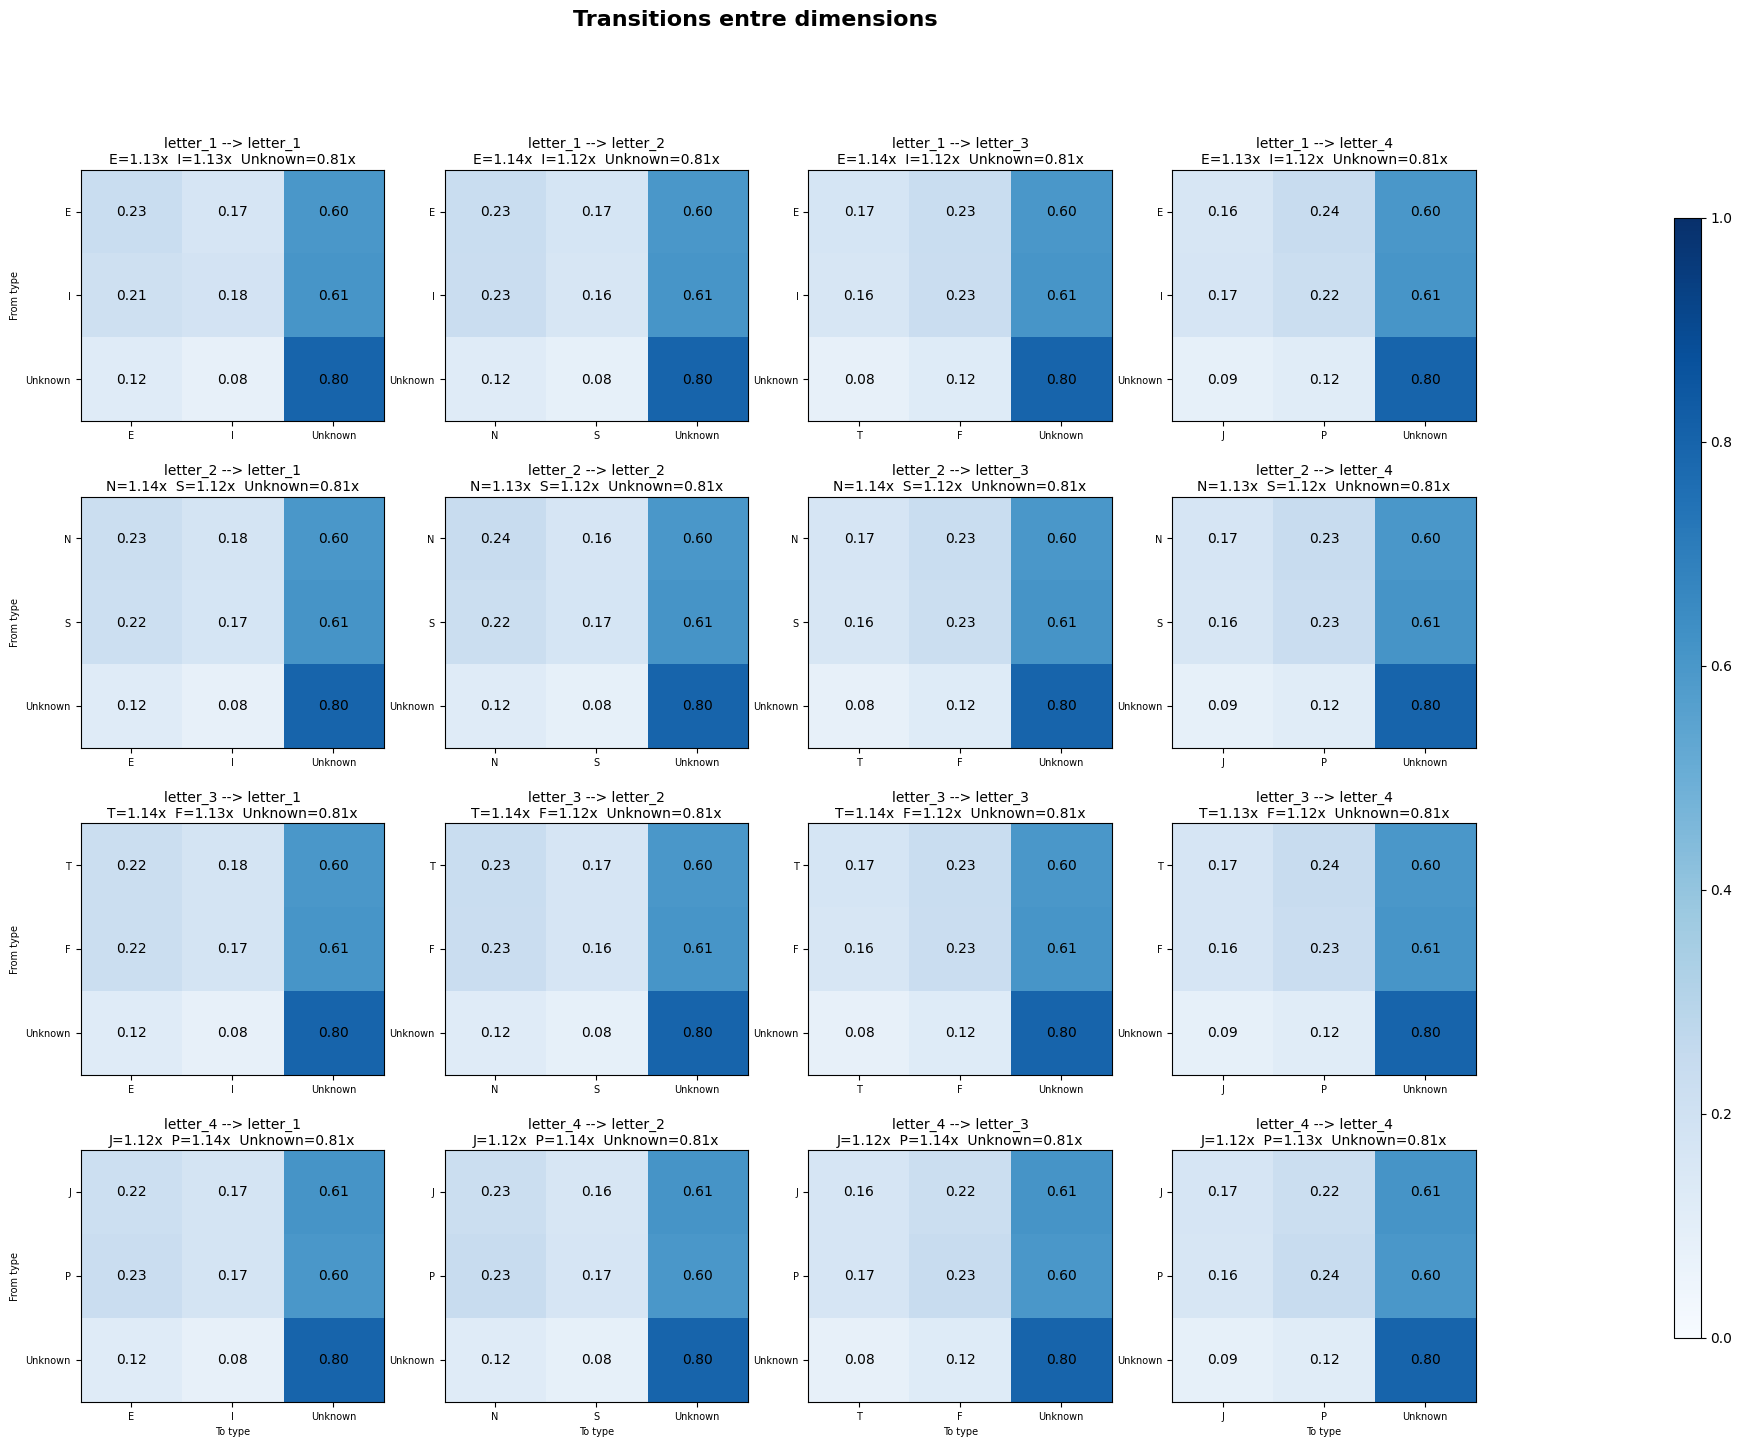

In [12]:
def plot_transition_matrix(stats) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS = {'letter_1': ['E', 'I', 'Unknown'],
                'letter_2': ['N', 'S', 'Unknown'],
                'letter_3': ['T', 'F', 'Unknown'],
                'letter_4': ['J', 'P', 'Unknown']}

    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    fig.suptitle("Transitions entre dimensions", fontsize=16, fontweight='bold')

    for i, src_dim in enumerate(DIMENSIONS) :
        for j, tgt_dim in enumerate(DIMENSIONS) :
            ax = axes[i][j]
            src_vals = LETTERS[src_dim]   # from (axe Y)
            tgt_vals = LETTERS[tgt_dim]   # to (axe X)

            # Probability matrix
            matrix = np.zeros((len(src_vals), len(tgt_vals)))
            for r, from_val in enumerate(src_vals) :
                entry = stats[src_dim][tgt_dim][from_val]
                total = entry[0]
                # Avoid division by 0
                if total > 0 :
                    for c in range(len(tgt_vals)) :
                        matrix[r, c] = entry[c + 1] / total

            # Lift 
            all_counts = np.zeros(len(tgt_vals))
            all_total = 0
            for from_val in src_vals :
                entry = stats[src_dim][tgt_dim][from_val]
                all_total += entry[0]
                for c in range(len(tgt_vals)) :
                    all_counts[c] += entry[c + 1]
            marginal = all_counts / all_total if all_total > 0 else np.ones(len(tgt_vals)) / len(tgt_vals)

            lift_per_row = []
            for r, from_val in enumerate(src_vals) :
                row_observed = matrix[r]
                row_expected = marginal  # expected distribution
                with np.errstate(divide='ignore', invalid='ignore') :
                    row_lift = np.nanmean(np.where(row_expected > 0, row_observed / row_expected, np.nan))
                lift_per_row.append(f"{from_val}={row_lift:.2f}x")

            im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues', aspect='auto')

            # Values in cell
            for r in range(len(src_vals)) :
                for c in range(len(tgt_vals)) :
                    ax.text(c, r, f"{matrix[r, c]:.2f}", ha='center', va='center', fontsize=10)

            # Set axes
            ax.set_xticks(range(len(tgt_vals)))
            ax.set_yticks(range(len(src_vals)))
            ax.set_xticklabels(tgt_vals, fontsize=7)
            ax.set_yticklabels(src_vals, fontsize=7)

            # Titre du subplot
            ax.set_title(f"{src_dim} --> {tgt_dim}\n" + "  ".join(lift_per_row), fontsize=10, pad=4)

            # Labels externes (seulement sur les bords)
            if i == 3 :
                ax.set_xlabel("To type", fontsize=7)
            if j == 0 :
                ax.set_ylabel("From type", fontsize=7)

    # Colorbar
    fig.subplots_adjust(wspace=0.2, hspace=0.3)
    cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    plt.savefig("Images/transition_matrix.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_transition_matrix(stats)

In [13]:
def compute_centralities_by_dimension(G) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS = {'letter_1': ['E', 'I', 'Unknown'],
                'letter_2': ['N', 'S', 'Unknown'],
                'letter_3': ['T', 'F', 'Unknown'],
                'letter_4': ['J', 'P', 'Unknown']}

    # Computing centrality
    degree_raw = dict(G.degree())
    betweenness_cent = nx.betweenness_centrality(G, normalized=True)
    pagerank = nx.pagerank(G)

    # Regroupement des noeuds par valeur pour chaque dimension
    results = {}

    for dim in DIMENSIONS :
        results[dim] = {}
        for val in LETTERS[dim] :

            # All nodes having this value for this dimension
            nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]

            if len(nodes) == 0 :
                results[dim][val] = {'n_nodes'           : 0,
                                    'degree_mean'        : None,
                                    'degree_median'      : None,
                                    'betweenness_mean'   : None,
                                    'betweenness_median' : None,
                                    'pagerank_mean'      : None,
                                    'pagerank_median'    : None}
                continue

            deg_vals = [degree_raw[n] for n in nodes]
            btw_vals = [betweenness_cent[n] for n in nodes]
            pr_vals  = [pagerank[n] for n in nodes]

            results[dim][val] = {'n_nodes'           : len(nodes),
                                'degree_mean'        : np.mean(deg_vals),
                                'degree_median'      : np.median(deg_vals),
                                'betweenness_mean'   : np.mean(btw_vals),
                                'betweenness_median' : np.median(btw_vals),
                                'pagerank_mean'      : np.mean(pr_vals),
                                'pagerank_median'    : np.median(pr_vals)}

    return results


def print_centralities(results) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS = {'letter_1': ['E', 'I', 'Unknown'],
                'letter_2': ['N', 'S', 'Unknown'],
                'letter_3': ['T', 'F', 'Unknown'],
                'letter_4': ['J', 'P', 'Unknown']}

    for dim in DIMENSIONS :
        print(f"\n{'='*60}")
        print(f"  Dimension : {dim}")
        print(f"{'='*60}")

        rows = []
        for val in LETTERS[dim] :
            r = results[dim][val]
            rows.append({
                'Value'              : val,
                'N nodes'            : r['n_nodes'],
                'Degree (mean)'      : f"{r['degree_mean']:<3.2f}"       if r['degree_mean']       is not None else 'N/A',
                'Degree (median)'    : f"{r['degree_median']:<3.2f}"     if r['degree_median']     is not None else 'N/A',
                'Betweenness (mean)' : f"{r['betweenness_mean']:<3.4f}"  if r['betweenness_mean']  is not None else 'N/A',
                'Betweenness (med.)' : f"{r['betweenness_median']:<3.4f}"if r['betweenness_median']is not None else 'N/A',
                'PageRank (mean)'    : f"{r['pagerank_mean']:<3.6f}"     if r['pagerank_mean']     is not None else 'N/A',
                'PageRank (med.)'    : f"{r['pagerank_median']:<3.6f}"   if r['pagerank_median']   is not None else 'N/A',
            })

        df = pd.DataFrame(rows).set_index('Value')
        print(df.to_string())


# Apply
centralities = compute_centralities_by_dimension(G)
print_centralities(centralities)


  Dimension : letter_1
         N nodes Degree (mean) Degree (median) Betweenness (mean) Betweenness (med.) PageRank (mean) PageRank (med.)
Value                                                                                                               
E           1397         40.32           24.00             0.0006             0.0001        0.000150        0.000097
I           1049         42.73           27.00             0.0007             0.0001        0.000160        0.000105
Unknown     9191         13.21            9.00             0.0001             0.0000        0.000068        0.000055

  Dimension : letter_2
         N nodes Degree (mean) Degree (median) Betweenness (mean) Betweenness (med.) PageRank (mean) PageRank (med.)
Value                                                                                                               
N           1422         41.89           26.00             0.0007             0.0001        0.000157        0.000103
S           1024

---
## Analysis with "Unknown" excluded

In [14]:
DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

# Exclude "Unknown"
nodes_to_keep = [n for n, attr in G.nodes(data=True)  if all(attr.get(dim) not in (None, 'Unknown') for dim in DIMENSIONS)]
G_filtered = G.subgraph(nodes_to_keep).copy()

print(f"Number of nodes before : {G.number_of_nodes():,}".replace(",", " "))
print(f"Number of nodes after  : {G_filtered.number_of_nodes():,}".replace(",", " "))
print(f"Number of links before : {G.number_of_edges():,}".replace(",", " "))
print(f"Number of links after  : {G_filtered.number_of_edges():,}".replace(",", " "))

# Rebuild the dictionary, same code as before without Unknown in LETTERS
LETTERS_FILTERED = {'letter_1': ['E', 'I'],
                    'letter_2': ['N', 'S'],
                    'letter_3': ['T', 'F'],
                    'letter_4': ['J', 'P']}

# Create dictionnary of links
def init_stats_dict_filtered() :
    stats = {}
    # From which dimension
    for src_dim in DIMENSIONS :
        stats[src_dim] = {}
        # To what dimension
        for tgt_dim in DIMENSIONS :
            stats[src_dim][tgt_dim] = {}
            # From which letter
            for from_val in LETTERS_FILTERED[src_dim]:
                # [totalLinks, Links_to_val1, Links_to_val2]
                stats[src_dim][tgt_dim][from_val] = [0, 0, 0]
    return stats

# Give the index to look at in the dictionnary
def get_val_filtered_index(tgt_dim, val) :
    possible = LETTERS_FILTERED[tgt_dim]
    return possible.index(val) + 1  # +1 car index 0 = total

def build_stats_filtered(G_filtered) :
    stats = init_stats_dict_filtered()

    for u, v in G_filtered.edges() :
        attrs_u = G_filtered.nodes[u]
        attrs_v = G_filtered.nodes[v]

        for src_dim in DIMENSIONS :
            from_val = attrs_u[src_dim]

            for tgt_dim in DIMENSIONS :
                to_val = attrs_v[tgt_dim]

                entry = stats[src_dim][tgt_dim][from_val]
                entry[0] += 1
                entry[get_val_filtered_index(tgt_dim, to_val)] += 1

    return stats

# Build dictionnary
stats_filtered = build_stats_filtered(G_filtered)

# Test
print("\n[Total links from E, From E to E, From E to I]")
print(stats_filtered['letter_1']['letter_1']['E'])
print("\n[Total links from I, From I to E, From I to I]")
print(stats_filtered['letter_1']['letter_1']['I'])

Number of nodes before : 11 637
Number of nodes after  : 2 446
Number of links before : 111 299
Number of links after  : 26 128

[Total links from E, From E to E, From E to I]
[14348, 8474, 5874]

[Total links from I, From I to E, From I to I]
[11780, 6384, 5396]


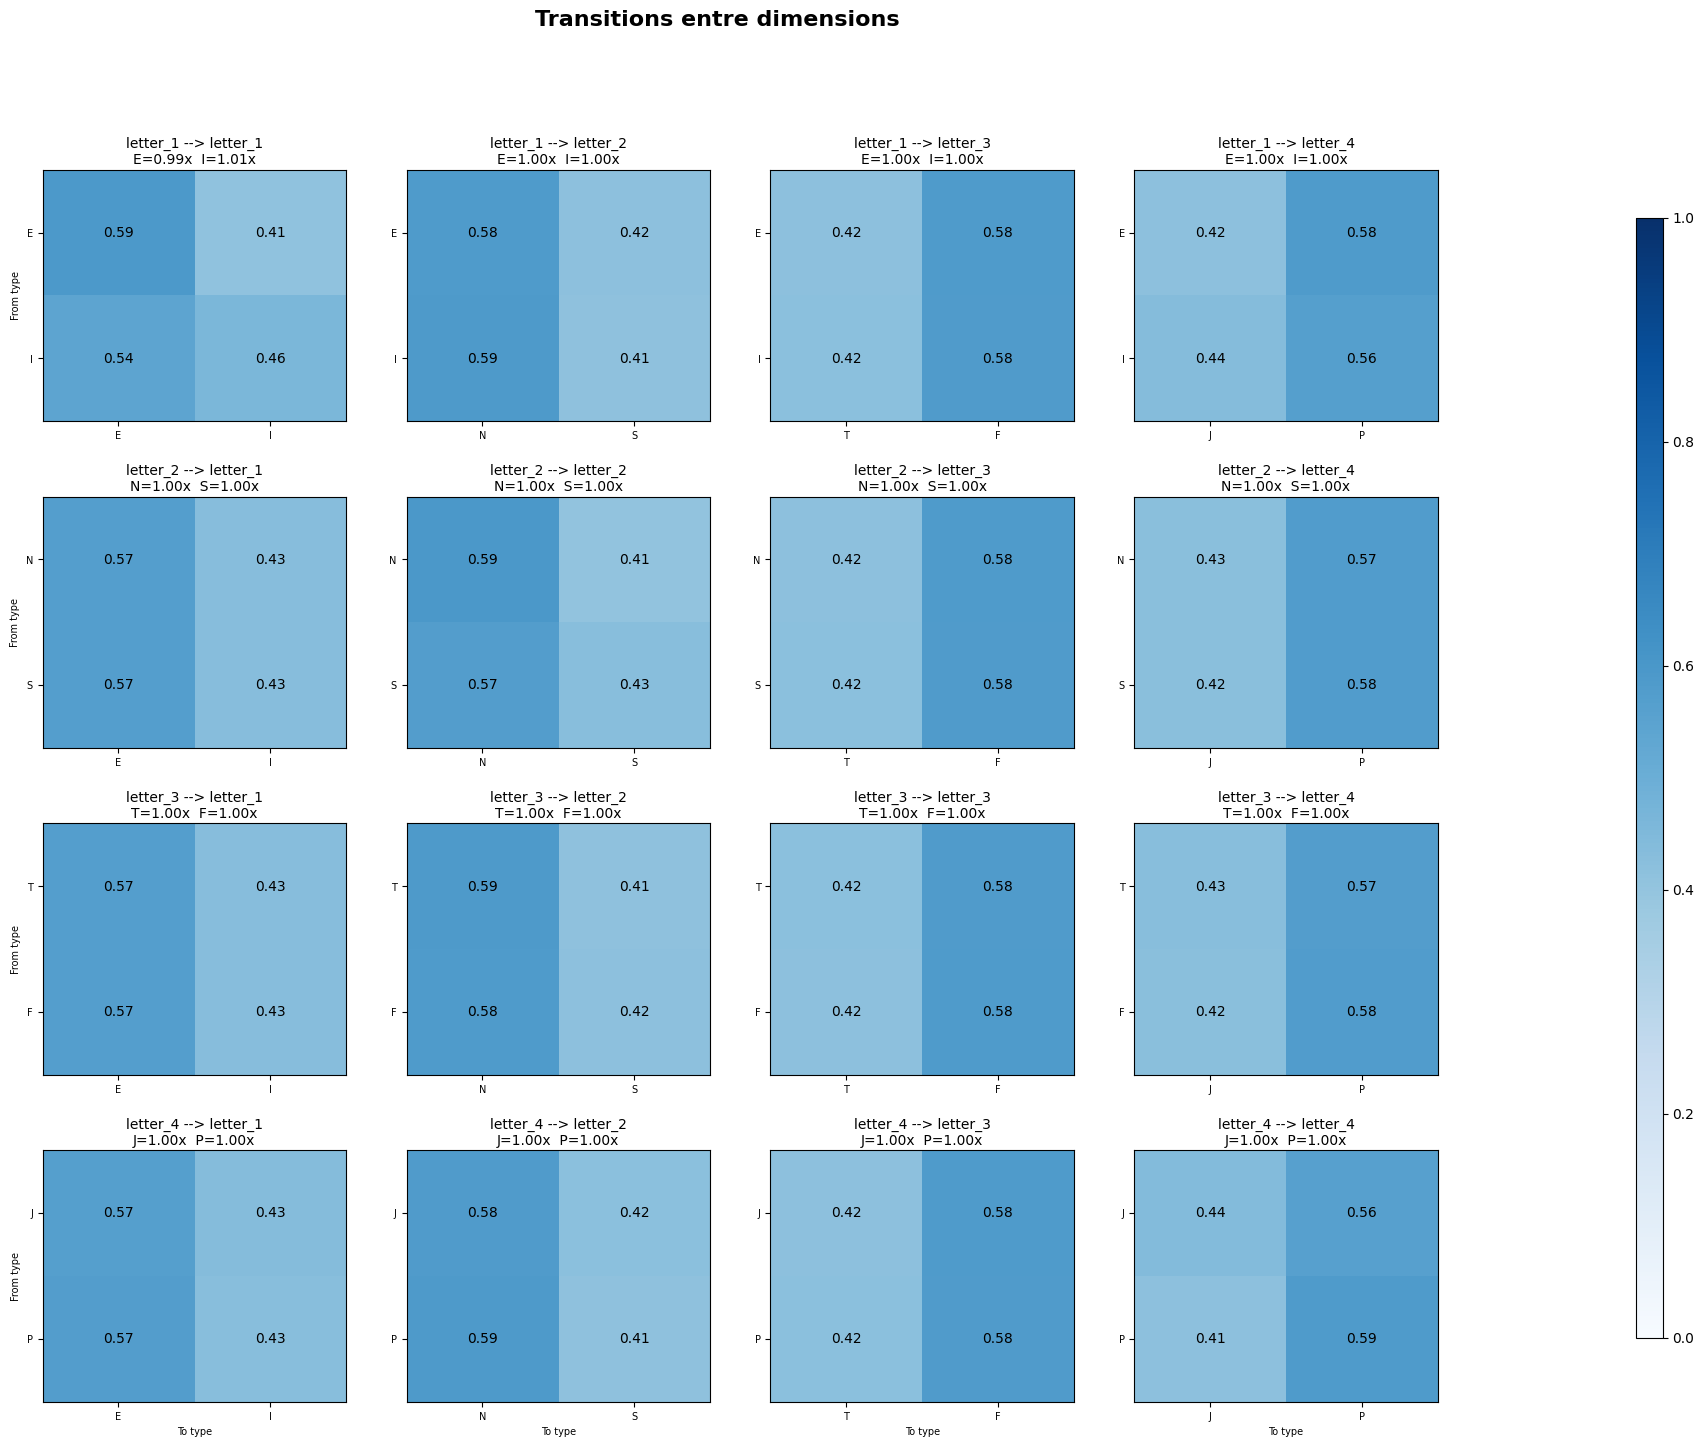

In [15]:
def plot_transition_matrix_filtered(stats) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS = {'letter_1': ['E', 'I'],
                'letter_2': ['N', 'S'],
                'letter_3': ['T', 'F'],
                'letter_4': ['J', 'P']}

    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    fig.suptitle("Transitions entre dimensions", fontsize=16, fontweight='bold')

    for i, src_dim in enumerate(DIMENSIONS) :
        for j, tgt_dim in enumerate(DIMENSIONS) :
            ax = axes[i][j]
            src_vals = LETTERS[src_dim]   # from (axe Y)
            tgt_vals = LETTERS[tgt_dim]   # to (axe X)

            # Probability matrix
            matrix = np.zeros((len(src_vals), len(tgt_vals)))
            for r, from_val in enumerate(src_vals) :
                entry = stats[src_dim][tgt_dim][from_val]
                total = entry[0]
                # Avoid division by 0
                if total > 0 :
                    for c in range(len(tgt_vals)) :
                        matrix[r, c] = entry[c + 1] / total

            # Lift 
            all_counts = np.zeros(len(tgt_vals))
            all_total = 0
            for from_val in src_vals :
                entry = stats[src_dim][tgt_dim][from_val]
                all_total += entry[0]
                for c in range(len(tgt_vals)) :
                    all_counts[c] += entry[c + 1]
            marginal = all_counts / all_total if all_total > 0 else np.ones(len(tgt_vals)) / len(tgt_vals)

            lift_per_row = []
            for r, from_val in enumerate(src_vals) :
                row_observed = matrix[r]
                row_expected = marginal  # expected distribution
                with np.errstate(divide='ignore', invalid='ignore') :
                    row_lift = np.nanmean(np.where(row_expected > 0, row_observed / row_expected, np.nan))
                lift_per_row.append(f"{from_val}={row_lift:.2f}x")

            im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues', aspect='auto')

            # Values in cell
            for r in range(len(src_vals)) :
                for c in range(len(tgt_vals)) :
                    ax.text(c, r, f"{matrix[r, c]:.2f}", ha='center', va='center', fontsize=10)

            # Set axes
            ax.set_xticks(range(len(tgt_vals)))
            ax.set_yticks(range(len(src_vals)))
            ax.set_xticklabels(tgt_vals, fontsize=7)
            ax.set_yticklabels(src_vals, fontsize=7)

            # Titre du subplot
            ax.set_title(f"{src_dim} --> {tgt_dim}\n" + "  ".join(lift_per_row), fontsize=10, pad=4)

            # Labels externes (seulement sur les bords)
            if i == 3 :
                ax.set_xlabel("To type", fontsize=7)
            if j == 0 :
                ax.set_ylabel("From type", fontsize=7)

    # Colorbar
    fig.subplots_adjust(wspace=0.2, hspace=0.3)
    cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    plt.savefig("Images/transition_matrix_filtered.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_transition_matrix_filtered(stats_filtered)

In [16]:
def compute_centralities_by_dimension_filtered(G) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS_FILTERED = {'letter_1': ['E', 'I'],
                'letter_2': ['N', 'S'],
                'letter_3': ['T', 'F'],
                'letter_4': ['J', 'P']}

    # Computing centrality
    degree_raw = dict(G.degree())
    betweenness_cent = nx.betweenness_centrality(G, normalized=True)
    pagerank = nx.pagerank(G)

    # Regroupement des noeuds par valeur pour chaque dimension
    results = {}

    for dim in DIMENSIONS :
        results[dim] = {}
        for val in LETTERS_FILTERED[dim] :

            # All nodes having this value for this dimension
            nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]

            if len(nodes) == 0 :
                results[dim][val] = {'n_nodes'           : 0,
                                    'degree_mean'        : None,
                                    'degree_median'      : None,
                                    'betweenness_mean'   : None,
                                    'betweenness_median' : None,
                                    'pagerank_mean'      : None,
                                    'pagerank_median'    : None}
                continue

            deg_vals = [degree_raw[n] for n in nodes]
            btw_vals = [betweenness_cent[n] for n in nodes]
            pr_vals  = [pagerank[n] for n in nodes]

            results[dim][val] = {'n_nodes'           : len(nodes),
                                'degree_mean'        : np.mean(deg_vals),
                                'degree_median'      : np.median(deg_vals),
                                'betweenness_mean'   : np.mean(btw_vals),
                                'betweenness_median' : np.median(btw_vals),
                                'pagerank_mean'      : np.mean(pr_vals),
                                'pagerank_median'    : np.median(pr_vals)}

    return results


def print_centralities_filtered(results) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS_FILTERED = {'letter_1': ['E', 'I'],
                'letter_2': ['N', 'S'],
                'letter_3': ['T', 'F'],
                'letter_4': ['J', 'P']}

    for dim in DIMENSIONS :
        print(f"\n{'='*60}")
        print(f"  Dimension : {dim}")
        print(f"{'='*60}")

        rows = []
        for val in LETTERS_FILTERED[dim] :
            r = results[dim][val]
            rows.append({
                'Value'              : val,
                'N nodes'            : r['n_nodes'],
                'Degree (mean)'      : f"{r['degree_mean']:<3.2f}"       if r['degree_mean']       is not None else 'N/A',
                'Degree (median)'    : f"{r['degree_median']:<3.2f}"     if r['degree_median']     is not None else 'N/A',
                'Betweenness (mean)' : f"{r['betweenness_mean']:<3.4f}"  if r['betweenness_mean']  is not None else 'N/A',
                'Betweenness (med.)' : f"{r['betweenness_median']:<3.4f}"if r['betweenness_median']is not None else 'N/A',
                'PageRank (mean)'    : f"{r['pagerank_mean']:<3.6f}"     if r['pagerank_mean']     is not None else 'N/A',
                'PageRank (med.)'    : f"{r['pagerank_median']:<3.6f}"   if r['pagerank_median']   is not None else 'N/A',
            })

        df = pd.DataFrame(rows).set_index('Value')
        print(df.to_string())


# Apply
centralities_filtered = compute_centralities_by_dimension_filtered(G_filtered)
print_centralities_filtered(centralities_filtered)


  Dimension : letter_1
       N nodes Degree (mean) Degree (median) Betweenness (mean) Betweenness (med.) PageRank (mean) PageRank (med.)
Value                                                                                                             
E         1397         20.91           12.00             0.0008             0.0001        0.000401        0.000273
I         1049         21.97           12.00             0.0008             0.0001        0.000419        0.000299

  Dimension : letter_2
       N nodes Degree (mean) Degree (median) Betweenness (mean) Betweenness (med.) PageRank (mean) PageRank (med.)
Value                                                                                                             
N         1422         21.70           13.00             0.0008             0.0001        0.000413        0.000292
S         1024         20.90           11.00             0.0008             0.0001        0.000403        0.000279

  Dimension : letter_3
       N